# Lab Experiment: Linear Regression through Gradient Descent

## Aim
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real world dataset.

## Objectives
- To understand the concept of Gradient Descent for optimizing a Linear Regression model.
- To preprocess the dataset before model training.
- To implement Linear Regression using Gradient Descent.
- To analyze the convergence of the loss function during training.
- To evaluate the model using standard regression metrics.


### 1. Download and load the Student Performance dataset.


In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('student+performance/student/student-mat.csv', sep=';')
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**Inference:** The Student Performance dataset is loaded successfully using pandas. We can observe that the dataset contains both numerical and categorical variables, and is delimited by semicolons.


### 2. Perform data preprocessing
Includes handling missing values, encoding categorical variables, and feature scaling.


In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Check for missing values
print("Missing values before:\n", df.isnull().sum().sum())

# Encode categorical variables using Label Encoding
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Display processed data
df.head()


Missing values before:
 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


**Inference:** We checked for missing values (none found) and converted categorical features (like sex, address, Pstatus, etc.) into numerical values using LabelEncoder so they can be processed by the regression model.


### 3. Select appropriate input features and target variable, and split the dataset.


In [3]:
from sklearn.model_selection import train_test_split

# Target variable is G3 (final grade)
y = df['G3'].values

# Input features (excluding G1, G2 to predict based on non-grade features, or we can include them)
# Let's drop the target G3
X = df.drop('G3', axis=1).values

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


X_train shape: (316, 32), X_test shape: (79, 32)


**Inference:** The target variable `G3` is separated from the features. The features are standardized using `StandardScaler` to ensure faster convergence of Gradient Descent. The dataset is split into 80% training and 20% testing sets.


### 4. Implement Linear Regression using the Gradient Descent algorithm.


In [4]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.iterations):
            # Predictions
            y_pred = np.dot(X, self.weights) + self.bias
            
            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Compute Mean Squared Error loss
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)
            
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


**Inference:** A custom `LinearRegressionGD` class is implemented. The `fit` method updates the weights and bias iteratively by calculating the gradient of the MSE cost function and stepping in the opposite direction by a factor of the learning rate.


### 5. Experiment with different learning rates and plot loss vs iterations.


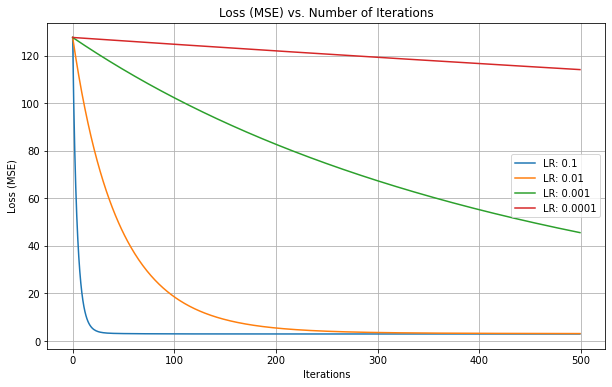

In [5]:
import matplotlib.pyplot as plt

learning_rates = [0.1, 0.01, 0.001, 0.0001]
iterations = 500
models = {}

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    model = LinearRegressionGD(learning_rate=lr, iterations=iterations)
    model.fit(X_train, y_train)
    models[lr] = model
    plt.plot(model.loss_history, label=f'LR: {lr}')

plt.title('Loss (MSE) vs. Number of Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


**Inference:** The plot illustrates the effect of learning rates. A larger learning rate (0.1) converges rapidly to the minimum loss, while a smaller learning rate (0.0001) converges very slowly. The loss curve successfully demonstrates how the cost function is minimized iteratively.


### 6. Evaluate the trained model using standard regression metrics.


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select the model with the best convergence (e.g., LR=0.01 or 0.1)
best_model = models[0.1]
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 1.4958
Mean Squared Error (MSE): 5.0324
Root Mean Squared Error (RMSE): 2.2433
R² Score: 0.7546


**Inference:** The model's predictions on the test set yield an R² score that evaluates its explanatory power. The MAE, MSE, and RMSE provide absolute measures of prediction errors, indicating the average deviation from the actual final grades (G3).
